# PRETRAINED YOLOV8 USING HARD HAT DETECTION CUSTOM DATASET FROM ROBOFLOW

## Mount google drive

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

## Install ultralytics to get the pretrained YOLOV8 MODEL

In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.8/914.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

## IMPORT NECCESSARY LIBRARIES

In [11]:
import os

from ultralytics import YOLO
import cv2

## 2. The root folder containing training and validation dataset

In [5]:
ROOT_DIR = '/content/gdrive/MyDrive/2025/Dataset/Hard_hat'

## Dataset information

The dataset is taken from Roboflow, which annotated 3 classes, head, helmet and human. This project detects heads and helmets, therefore, the human annotated images are removed.

## Delete labels which detech humans

In [12]:
# Delete labels with class 2
path = "/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/labels/train"
txt_files = [f for f in os.listdir(path)]
deleted_files = []
# Read each .txt file line by line
for txt_file in txt_files:
    with open(os.path.join(path, txt_file), 'r') as file:
        lines = file.readlines()  # This reads the file line by line
        print(f'Contents of {txt_file}:')
        for line in lines:
            class_label = line.strip()[0] # strip() removes the trailing newline character
            if class_label == '2':
              deleted_files.append(txt_file)
              break

        print()  # Empty line between files





KeyboardInterrupt: 

In [ ]:
paths = "/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/labels/train"
for file in deleted_files:
  file_path = os.path.join(paths, file)
  print(file_path)

In [ ]:
# Loop through the paths and delete the files
#path = "/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/labels/train"

paths = "/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/labels/train"
# for file in deleted_files:
#   file_path = os.path.join(paths, file)
#   print(file_path)
for file in deleted_files:
    file_path = os.path.join(paths, file)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Deleted: {file_path}")
    else:
        print(f"File not found: {file_path}")

In [ ]:
num_deleted_imgs = [num[:6] for num in deleted_files]
img_paths = "/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/images/train"
# for file in deleted_files:
#   file_path = os.path.join(paths, file)
#   print(file_path)
# for file in deleted_files:
#     file_path = os.path.join(paths, file)

images_deleted_list = []
imgs_files = [f for f in os.listdir(img_paths)]
for img in imgs_files:
  img_num = img[:6]
  if img_num in num_deleted_imgs:
    images_deleted_list.append(os.path.join(img_paths,img))
for file in images_deleted_list:

    if os.path.exists(file):
        os.remove(file)
        print(f"Deleted: {file}")
    else:
        print(f"File not found: {file}")

## Delete validation files

In [ ]:
# Delete labels with class 2
path = "/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/labels/val"
txt_files = [f for f in os.listdir(path)]
deleted_files = []
# Read each .txt file line by line
for txt_file in txt_files:
    with open(os.path.join(path, txt_file), 'r') as file:
        lines = file.readlines()  # This reads the file line by line
        print(f'Contents of {txt_file}:')
        for line in lines:
            class_label = line.strip()[0] # strip() removes the trailing newline character
            if class_label == '2':
              deleted_files.append(txt_file)
              break

        print()  # Empty line between files

paths = "/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/labels/val"
for file in deleted_files:
  file_path = os.path.join(paths, file)
  print(file_path)

with open("deleted_files.txt", "w") as file:
    for item in deleted_files:
        file.write(f"{item}\n")


# Loop through the paths and delete the files
#path = "/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/labels/train"

paths = "/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/labels/val"
# for file in deleted_files:
#   file_path = os.path.join(paths, file)
#   print(file_path)
for file in deleted_files:
    file_path = os.path.join(paths, file)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Deleted: {file_path}")
    else:
        print(f"File not found: {file_path}")


num_deleted_imgs = [num[:6] for num in deleted_files]
img_paths = "/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/images/val"
# for file in deleted_files:
#   file_path = os.path.join(paths, file)
#   print(file_path)
# for file in deleted_files:
#     file_path = os.path.join(paths, file)

images_deleted_list = []
imgs_files = [f for f in os.listdir(img_paths)]
for img in imgs_files:
  img_num = img[:6]
  if img_num in num_deleted_imgs:
    images_deleted_list.append(os.path.join(img_paths,img))
for file in images_deleted_list:

    if os.path.exists(file):
        os.remove(file)
        print(f"Deleted: {file}")
    else:
        print(f"File not found: {file}")

Contents of 000134_jpg.rf.2216ce4f4aa7db3dbf3bc8ea74f1083f.txt:

Contents of 000133_jpg.rf.7727356df55809eea80a35c40e7a62dd.txt:

Contents of 000136_jpg.rf.bd59a3b1744cd77a24a66294d9cc0ee5.txt:

Contents of 000135_jpg.rf.0ca2fda801cbc26acad48a4970d5fd9c.txt:

Contents of 000141_jpg.rf.a0083a17eefa1c9b49f5326d7a0ff987.txt:

Contents of 000137_jpg.rf.afa196bd1073d38ed93a48f6f5612e41.txt:

Contents of 000132_jpg.rf.c9102cf1cad5f4ca9e84ae4b0afb0283.txt:

Contents of 000120_jpg.rf.8ae3d79f4828c94ff29ee01c03f92303.txt:

Contents of 000118_jpg.rf.0245b0832f29603d3f9249d0922cd942.txt:

Contents of 000119_jpg.rf.17e0c2452ada10da7da40c095deb6f30.txt:

Contents of 000131_jpg.rf.41f1959e530db31eeb1b751f9dd136f2.txt:

Contents of 000130_jpg.rf.d7f4949abf806c22b4bb89e9289f607e.txt:

Contents of 000129_jpg.rf.bd9f7a05de307d65bdd3641f37310608.txt:

Contents of 000128_jpg.rf.c82d76fc6ef2bfc6d34988ce3277aa19.txt:

Contents of 000115_jpg.rf.083e9c5cab3f5899902022dda126e200.txt:

Contents of 000116_jpg.rf

## Model training

In [102]:
model = YOLO("yolov8n.pt")  # Download the pretrained YOLOV8 model

# Use the model to pretrained on custom helmet dataset, using only 20 epochs.
trained_model = model.train(data=os.path.join(ROOT_DIR, "/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data_config.yaml"), epochs=20)  # Train mô hình


Ultralytics 8.3.72 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (AMD EPYC 7B12)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/gdrive/MyDrive/2025/Dataset/Hard_hat/data_config.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train15, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tr

train: Scanning /content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/labels/train.cache... 4722 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4722/4722 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/labels/val... 383 images, 0 backgrounds, 0 corrupt: 100%|██████████| 383/383 [00:02<00:00, 139.51it/s]


val: New cache created: /content/gdrive/MyDrive/2025/Dataset/Hard_hat/data/labels/val.cache
Plotting labels to runs/detect/train15/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs/detect/train15
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      20/20         0G      1.067     0.4619       1.01         10        640: 100%|██████████| 296/296 [15:11<00:00,  3.08s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:20<00:00,  1.72s/it]

                   all        383       1531      0.948      0.931      0.976      0.685



20 epochs completed in 5.164 hours.
Optimizer stripped from runs/detect/train15/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train15/weights/best.pt, 6.2MB

Validating runs/detect/train15/weights/best.pt...
Ultralytics 8.3.72 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (AMD EPYC 7B12)
Model summary (fused): 168 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:18<00:00,  1.53s/it]


                   all        383       1531      0.948      0.931      0.976      0.686
                  head         71        409      0.934      0.929      0.968      0.682
                helmet        345       1122      0.962      0.932      0.983       0.69
Speed: 0.8ms preprocess, 36.9ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/train15


In [103]:
# Copy trained_model and related metrics

!scp -r /content/runs '/content/gdrive/MyDrive/2025/Projects/Hard_hat/'

In [9]:
# Save the pretrained model on helmet dataset (hard hat)

model.save(os.path.join(ROOT_DIR, "trained_model_hard_hat.pt"))

In [6]:
# Load the pretrained YOLOV8 to use

model = YOLO(os.path.join(ROOT_DIR, "trained_model_hard_hat.pt"))
model.eval()

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

## INFERENCE

On images and video

In [7]:
# Test on images
results = model(["/content/1.jpg", "/content/2.jpg"])
results


0: 640x640 1 head, 2 helmets, 76.1ms
1: 640x640 1 head, 4 helmets, 76.1ms
Speed: 4.0ms preprocess, 76.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'head', 1: 'helmet'}
 obb: None
 orig_img: array([[[ 94,  62,  43],
         [ 94,  62,  43],
         [ 94,  62,  43],
         ...,
         [ 94,  62,  43],
         [ 94,  62,  43],
         [ 94,  62,  43]],
 
        [[ 94,  62,  43],
         [ 94,  62,  43],
         [ 95,  63,  44],
         ...,
         [ 94,  62,  43],
         [ 94,  62,  43],
         [ 94,  62,  43]],
 
        [[ 94,  62,  43],
         [ 95,  63,  44],
         [ 95,  63,  44],
         ...,
         [ 94,  62,  43],
         [ 94,  62,  43],
         [ 94,  62,  43]],
 
        ...,
 
        [[ 61,  79,  96],
         [ 73,  91, 108],
         [ 72,  91, 106],
         ...,
         [ 68,  90, 102],
         [ 65,  87,  99],
         [ 63,  85,  97]],
 
        [[ 58,  76,  93],
         [ 72,  90, 107],
         [ 69,  88, 103],
         ...,
       

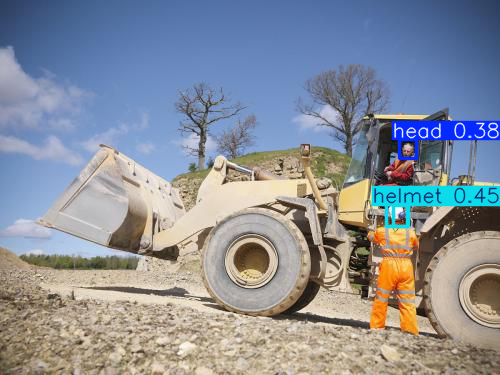

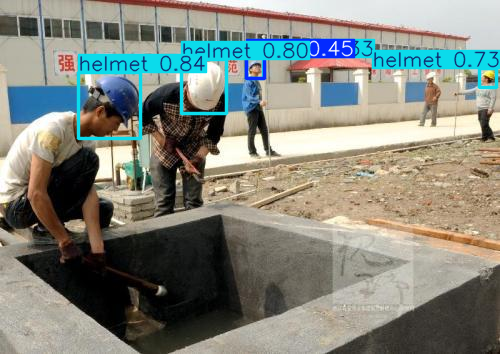

In [8]:
# Print out the bounding box and images
# Process results list
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    result.show()  # display to screen
    result.save(filename="result.jpg")  # save to disk

In [10]:
# Test on video, a random video taken from Youtube
# Open the input video
video_path = "/content/Construction Laborers.mp4"
cap = cv2.VideoCapture(video_path)

# Get video properties
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
output_path = "/content/output_video.mp4"

# Define the codec and create a VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break  # End of video

    # Run YOLO inference
    results = model(frame)
    annotated_frame = results[0].plot()

    # Convert frame to correct format before writing
    annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR)
    out.write(annotated_frame)

cap.release()
out.release()
cv2.destroyAllWindows()


Streaming output truncated to the last 5000 lines.
0: 384x640 1 helmet, 62.5ms
Speed: 2.7ms preprocess, 62.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 helmet, 71.3ms
Speed: 2.3ms preprocess, 71.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 helmet, 82.8ms
Speed: 5.6ms preprocess, 82.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 helmet, 61.6ms
Speed: 3.6ms preprocess, 61.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 helmet, 62.5ms
Speed: 2.9ms preprocess, 62.5ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 helmet, 70.7ms
Speed: 5.2ms preprocess, 70.7ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 helmet, 59.8ms
Speed: 5.6ms preprocess, 59.8ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 helmet, 62.2ms
Speed: 2.1ms preprocess, 62.2ms inferen